# Erg Video Analysis

## Pose Estimation and Key Joint Angle Extraction

### Approach

1. Use MediaPipe Pose Landmarker from Google ([Link](https://developers.google.com/edge/mediapipe/solutions/vision/pose_landmarker/index?_gl=1*z8jxl0*_up*MQ..*_ga*NDE0OTUwMzcwLjE3OTA4NzQyMzU.*_ga_SM8HXJ53K2*czE3OTA4NzQyMzQkbzEkZzAkdDE3OTA4NzQyNDckajQ3JGwwJGgw#models)), which, given a frame of a human, returns 33 key landmarks on human body.
2. Extract key landmarks for rowing analysis:
    - knee
    - hip
    - elbow
    - shoulder
    - ankle
    - trunk lean

3. Calculate angles involving these key joints
4. Annotate frame with the landmarks, connections between landmarks, and key angles
5. Use this process for each frame of a video, to obtain an annotated video





In [1]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# setup pose landmarker 


from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = "../models/pose_landmarker_full.task"

base_options = python.BaseOptions(
    model_asset_path=model_path
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1
)

landmarker = vision.PoseLandmarker.create_from_options(options)

In [3]:
# capture a frame from the video

cap = cv2.VideoCapture("../assets/luke-erg.mp4")

ret, frame = cap.read()

cap.release()

print(frame.shape)

(2160, 3840, 3)


(-0.5, 3839.5, 2159.5, -0.5)

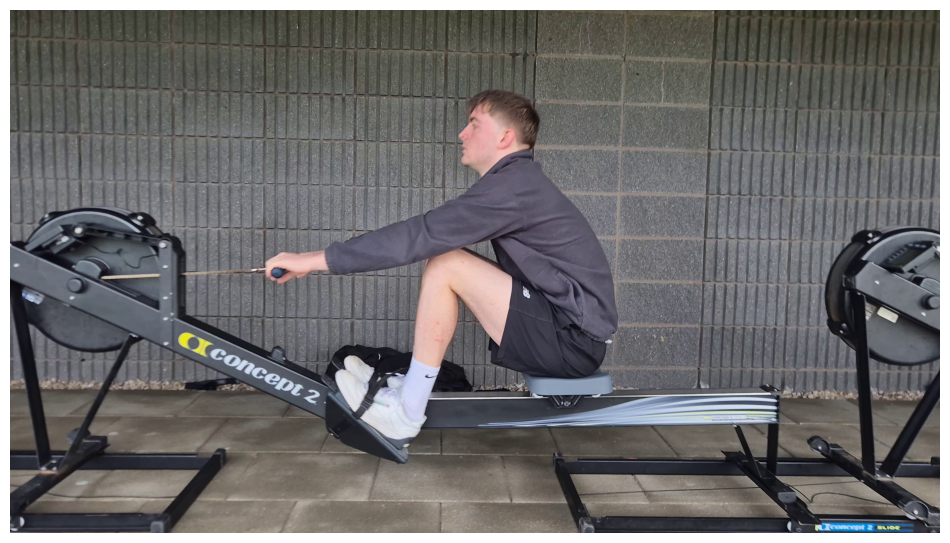

In [4]:
# display the captured frame

plt.figure(figsize=(12, 7))

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

plt.axis("off")

In [5]:
# run pose estimation on captured frame

rbg_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB, 
    data=rbg_frame)

result = landmarker.detect(mp_image)

len(result.pose_landmarks)

1

In [6]:
landmarks = result.pose_landmarks[0]

len(landmarks)

33

In [7]:
# display pose landmarks

for i, landmark in enumerate(landmarks):
    print(
        i, 
        round(landmark.x, 3),
        round(landmark.y, 3),
        round(landmark.z, 3), 
        round(landmark.visibility, 3),
    )

0 0.492 0.251 0.002 0.999
1 0.5 0.229 -0.02 0.999
2 0.503 0.229 -0.021 0.999
3 0.505 0.229 -0.021 1.0
4 0.499 0.228 0.018 1.0
5 0.5 0.228 0.018 1.0
6 0.501 0.227 0.018 1.0
7 0.521 0.241 -0.072 0.999
8 0.518 0.237 0.101 0.999
9 0.498 0.274 -0.014 0.999
10 0.496 0.273 0.036 0.999
11 0.535 0.349 -0.181 0.999
12 0.534 0.363 0.227 0.998
13 0.429 0.433 -0.25 0.917
14 0.448 0.452 0.259 0.023
15 0.325 0.48 -0.208 0.941
16 0.356 0.484 0.197 0.061
17 0.295 0.495 -0.249 0.937
18 0.342 0.485 0.21 0.09
19 0.293 0.49 -0.212 0.927
20 0.326 0.491 0.172 0.089
21 0.3 0.487 -0.194 0.892
22 0.332 0.487 0.178 0.096
23 0.6 0.633 -0.136 1.0
24 0.598 0.633 0.136 0.999
25 0.471 0.489 -0.127 0.973
26 0.473 0.491 0.273 0.044
27 0.421 0.737 -0.027 0.985
28 0.429 0.718 0.398 0.212
29 0.425 0.805 -0.018 0.971
30 0.444 0.762 0.409 0.254
31 0.348 0.702 -0.05 0.969
32 0.377 0.711 0.384 0.293


In [8]:
# draw pose landmarks and connections on the captured frame

connections = mp.tasks.vision.PoseLandmarksConnections.POSE_LANDMARKS
annotated = frame.copy()

height, width = frame.shape[:2]

for connection in connections:

    start_idx, end_idx = connection.start, connection.end

    start = landmarks[start_idx]
    end = landmarks[end_idx]

    start_point = (
        int(start.x * width),
        int(start.y * height)
    )

    end_point = (
        int(end.x * width),
        int(end.y * height)
    )

    cv2.line(
        annotated,
        start_point,
        end_point,
        (0, 255, 0),
        2
    )

for landmark in landmarks:

    point = (
        int(landmark.x * width),
        int(landmark.y * height)
    )

    cv2.circle(
        annotated,
        point,
        5,
        (255, 0, 0),
        -1
    )

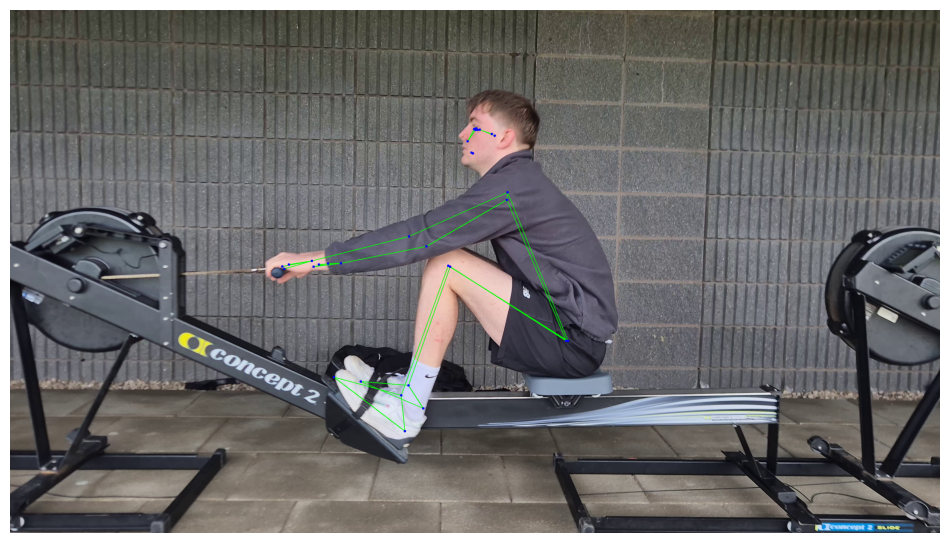

In [9]:
# display the annotated frame with pose landmarks and connections

plt.figure(figsize=(12, 7))

plt.imshow(
    cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
)

plt.axis("off");

In [10]:
# map landmarks to strings for rowing analysis
ROWING_LANDMARKS: dict[str, int] = {
    "nose": 0,
    "left_ear": 7,
    "right_ear": 8,
    "left_shoulder": 11,
    "right_shoulder": 12,
    "left_elbow": 13,
    "right_elbow": 14,
    "left_wrist": 15,
    "right_wrist": 16,
    "left_hip": 23,
    "right_hip": 24,
    "left_knee": 25,
    "right_knee": 26,
    "left_ankle": 27,
    "right_ankle": 28,
    "left_heel": 29,
    "right_heel": 30,
    "left_foot_index": 31,
    "right_foot_index": 32,
}

In [11]:
# convert landmark to pixel coordinates

def get_point(landmark, width, height):
    return np.array([landmark.x * width, landmark.y * height])


In [12]:
# calculate the angle formed by three points (a, b, c) in 2D space. the angle is at point b

def calculate_angle(a, b, c):
    ba = a - b
    bc = c - b
    ba_length = np.linalg.norm(ba)
    bc_length = np.linalg.norm(bc)
    if np.isclose(ba_length, 0) or np.isclose(bc_length, 0):
        raise ValueError("Cannot calculate an angle with coincident landmarks.")

    cosine_angle = np.dot(ba, bc) / (ba_length * bc_length)
    return float(np.degrees(np.arccos(np.clip(cosine_angle, -1, 1))))


In [13]:

# calculate rowing angles for given landmarks in an image
# key angles are
# - knee
# - hip
# - elbow
# - shoulder
# - ankle
# - trunk lean
def calculate_rowing_angles(landmarks, width, height):
    def point(name):
        return get_point(landmarks[ROWING_LANDMARKS[name]], width, height)

    angles = {}
    for side in ("left", "right"):
        angles[f"{side}_knee"] = calculate_angle(
            point(f"{side}_hip"), point(f"{side}_knee"), point(f"{side}_ankle")
        )
        angles[f"{side}_hip"] = calculate_angle(
            point(f"{side}_shoulder"), point(f"{side}_hip"), point(f"{side}_knee")
        )
        angles[f"{side}_elbow"] = calculate_angle(
            point(f"{side}_shoulder"), point(f"{side}_elbow"), point(f"{side}_wrist")
        )
        angles[f"{side}_shoulder"] = calculate_angle(
            point(f"{side}_hip"), point(f"{side}_shoulder"), point(f"{side}_elbow")
        )
        angles[f"{side}_ankle"] = calculate_angle(
            point(f"{side}_knee"), point(f"{side}_ankle"), point(f"{side}_foot_index")
        )

    shoulder_midpoint = (point("left_shoulder") + point("right_shoulder")) / 2
    hip_midpoint = (point("left_hip") + point("right_hip")) / 2
    horizontal = shoulder_midpoint[0] - hip_midpoint[0]
    vertical = hip_midpoint[1] - shoulder_midpoint[1]
    if np.isclose(np.hypot(horizontal, vertical), 0):
        raise ValueError("Cannot calculate trunk lean with coincident shoulder and hip points.")
    angles["trunk_lean"] = float(np.degrees(np.arctan2(abs(horizontal), vertical)))
    return angles



In [14]:

rowing_angles = calculate_rowing_angles(landmarks, width, height)
for angle_name, angle_degrees in rowing_angles.items():
    print(f"{angle_name}: {angle_degrees:.1f} degrees")

left_knee: 77.8 degrees
left_hip: 35.8 degrees
left_elbow: 170.2 degrees
left_shoulder: 88.1 degrees
left_ankle: 94.9 degrees
right_knee: 76.8 degrees
right_hip: 34.6 degrees
right_elbow: 161.0 degrees
right_shoulder: 82.8 degrees
right_ankle: 104.7 degrees
trunk_lean: 22.5 degrees


In [15]:
# draw joint angles, landmarks, connections

def annotate_frame(frame, landmarks, rowing_angles, width, height, display=False):
    annotated = frame.copy()
    connections = mp.tasks.vision.PoseLandmarksConnections.POSE_LANDMARKS

    for connection in connections:
        start = landmarks[connection.start]
        end = landmarks[connection.end]
        start_point = (round(start.x * width), round(start.y * height))
        end_point = (round(end.x * width), round(end.y * height))
        cv2.line(annotated, start_point, end_point, (0, 255, 0), 2)

    for landmark in landmarks:
        point = (round(landmark.x * width), round(landmark.y * height))
        cv2.circle(annotated, point, 5, (255, 0, 0), -1)

    font_scale = max(0.55, width / 3200)
    text_thickness = max(1, round(font_scale * 1.5))
    joint_for_angle = {
        "knee": "knee",
        "hip": "hip",
        "elbow": "elbow",
        "shoulder": "shoulder",
        "ankle": "ankle",
    }
    short_name = {
        "knee": "K",
        "hip": "H",
        "elbow": "E",
        "shoulder": "S",
        "ankle": "A",
    }

    for side in ("left", "right"):
        for angle_name, joint_name in joint_for_angle.items():
            angle = rowing_angles[f"{side}_{angle_name}"]
            joint = get_point(landmarks[ROWING_LANDMARKS[f"{side}_{joint_name}"]], width, height)
            text = f"{short_name[angle_name]} {side[0].upper()}: {angle:.1f}"
            (text_width, text_height), baseline = cv2.getTextSize(
                text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_thickness
            )
            side_offset = round(width * 0.012)
            if side == "left":
                text_x = round(joint[0]) - side_offset - text_width
            else:
                text_x = round(joint[0]) + side_offset
            text_y = round(joint[1]) - round(text_height / 2)
            text_x = min(max(text_x, 2), width - text_width - 4)
            text_y = min(max(text_y, text_height + baseline + 2), height - baseline - 2)
            cv2.rectangle(
                annotated,
                (text_x - 3, text_y - text_height - 3),
                (text_x + text_width + 3, text_y + baseline + 2),
                (20, 20, 20),
                cv2.FILLED,
            )
            cv2.putText(
                annotated,
                text,
                (text_x, text_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                (0, 220, 255),
                text_thickness,
                cv2.LINE_AA,
            )

    shoulder_midpoint = (
        get_point(landmarks[ROWING_LANDMARKS["left_shoulder"]], width, height)
        + get_point(landmarks[ROWING_LANDMARKS["right_shoulder"]], width, height)
    ) / 2
    hip_midpoint = (
        get_point(landmarks[ROWING_LANDMARKS["left_hip"]], width, height)
        + get_point(landmarks[ROWING_LANDMARKS["right_hip"]], width, height)
    ) / 2
    trunk_midpoint = (shoulder_midpoint + hip_midpoint) / 2
    trunk_text = f"Trunk: {rowing_angles['trunk_lean']:.1f}"
    (trunk_width, trunk_height), trunk_baseline = cv2.getTextSize(
        trunk_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_thickness
    )
    trunk_x = min(max(round(trunk_midpoint[0] - trunk_width / 2), 2), width - trunk_width - 4)
    trunk_y = min(max(round(trunk_midpoint[1]), trunk_height + trunk_baseline + 2), height - trunk_baseline - 2)
    cv2.rectangle(
        annotated,
        (trunk_x - 3, trunk_y - trunk_height - 3),
        (trunk_x + trunk_width + 3, trunk_y + trunk_baseline + 2),
        (20, 20, 20),
        cv2.FILLED,
    )
    cv2.putText(
        annotated,
        trunk_text,
        (trunk_x, trunk_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        (0, 220, 255),
        text_thickness,
        cv2.LINE_AA,
    )

    if display:
        plt.figure(figsize=(12, 7))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.axis("off");
    return annotated

In [16]:
# processes video and annotates it with pose landmarks and rowing angles per frame

def process_video(input_path, output_path):
    options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    )

    landmarker = vision.PoseLandmarker.create_from_options(options)
    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        raise RuntimeError("Could not open input video.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if fps <= 0 or width <= 0 or height <= 0:
        cap.release()
        landmarker.close()
        raise RuntimeError("Could not read valid video properties.")

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )

    if not writer.isOpened():
        cap.release()
        landmarker.close()
        raise RuntimeError("Could not open output video for writing.")

    frame_index = 0

    try:
        while True:
            success, frame = cap.read()
            if not success:
                break

            timestamp_ms = round(frame_index * 1000 / fps)
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            result = landmarker.detect_for_video(mp_image, timestamp_ms)

            if result.pose_landmarks:
                landmarks = result.pose_landmarks[0]
                angles = calculate_rowing_angles(landmarks, width, height)

                annotated = annotate_frame(frame, landmarks, angles, width, height)
            else:
                annotated = frame

            writer.write(annotated)
            frame_index += 1
    finally:
        cap.release()
        writer.release()
        landmarker.close()


In [17]:
# process_video("../assets/alex-erg.mp4", "../assets/alex-erg-analyzed.mp4")

In [18]:
import subprocess
import imageio_ffmpeg

# converts video to h.264 format for easier previewing

def convert_to_h264(input_path, output_path, crf=23):
    
    subprocess.run(
        [
            imageio_ffmpeg.get_ffmpeg_exe(), "-y", "-i", input_path,
            "-c:v", "libx264", "-pix_fmt", "yuv420p",
            "-crf", str(crf), "-preset", "veryfast",
            "-movflags", "+faststart", output_path,
        ],
        check=True,
        capture_output=True,
    )




In [19]:
# convert_to_h264("../assets/alex-erg-analyzed.mp4", "../assets/alex-erg-analyzed-h264.mp4")

## Stroke Phase Detection

## How To Detect Phases of Stroke

### Catch
- the local extreme where the handle is the closest to the flywheel
- seat is also closest to flywheel
- knees are most compressed
- shins near vertical

### Drive
- from catch until the finish
- handle moves away from flywheel
- legs extend, then trunk/hips, then arms

### Finish
- handle is closest to the body/ furthest from flywheel
- legs fully extended
- elbows most back

### Recovery
- from finish to catch
- arms extend, then trunk/hips lean over, then legs compress

### Approach

1. Run pose estimation on every frame and keep the landmarks and joint angles as time series
2. Build a 1D handle position signal using average of two wrists
    - Wrists projected onto the principal axis of motion
    - Oriented so that low values = catch and high values = finish
3. Find the catch (valleys) and finish (peaks) with `scipy.signal.find_peaks`, then label drive / recovery between them
    - Allowing us to calculate rate, drive time, recovery time and drive:recovery ratio
    - Catch and finish are 10% windows around the extreme values (configurable as argument to `detect_strokes`)

4. Validate each stroke with the knee angle and stroke rate
    - Only accepts spm 10-50 (configurable as argument to `detect_strokes`)
    - Knee angle must be more bent at catch than finish

5. Overlay stroke data on video alongside pose estimation data
    - Stroke no, stroke phase, rate, drive time, recovery time and drive:recovery ratio

### Configurable Thresholds

The `detect_strokes` function has several configurable thresholds

1. min_spm
    - Minimum strokes per minute accepted by function
    - Strokes with slower spm are not accepted (presumed to be noise)

2. max_spm
    - Minimum strokes per minute accepted by function
    - Strokes with higher spm are not accepted (presumed to be noise)

3. prominence
    - Minimum prominence of peaks/valleys in handle signal
    - This is how far a peak stands out from the surrounding signal


4. window_frac
    - Fraction of stroke duration to label as catch/finish window

In [27]:
from types import SimpleNamespace
from scipy.signal import find_peaks, savgol_filter

# run pose estimation on a whole video and keep per-frame pixel landmarks (x, y, visibility) and angles

def extract_pose_series(video_path):
    video_options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
    )
    video_landmarker = vision.PoseLandmarker.create_from_options(video_options)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        video_landmarker.close()
        raise RuntimeError("Could not open input video.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    if fps <= 0 or width <= 0 or height <= 0:
        cap.release()
        video_landmarker.close()
        raise RuntimeError("Could not read valid video properties.")

    points, angles = [], []
    frame_index = 0
    try:
        while True:
            success, frame = cap.read()
            if not success:
                break
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            result = video_landmarker.detect_for_video(mp_image, round(frame_index * 1000 / fps))

            frame_points = np.full((33, 3), np.nan)
            frame_angles = None
            if result.pose_landmarks:
                frame_landmarks = result.pose_landmarks[0]
                for i, lm in enumerate(frame_landmarks):
                    frame_points[i] = (lm.x * width, lm.y * height, lm.visibility)
                try:
                    frame_angles = calculate_rowing_angles(frame_landmarks, width, height)
                except ValueError:
                    pass
            points.append(frame_points)
            angles.append(frame_angles)
            frame_index += 1
    finally:
        cap.release()
        video_landmarker.close()

    return fps, width, height, np.array(points), angles

In [28]:
# fill NaN gaps by linear interpolation

def interpolate_nans(values):
    values = np.asarray(values, dtype=float)
    valid = ~np.isnan(values)
    if valid.sum() < 2:
        raise ValueError("Not enough valid frames to interpolate.")
    return np.interp(np.arange(len(values)), np.flatnonzero(valid), values[valid])


# mean of an angle over both sides for every frame (NaN where pose was not detected)

def angle_series(angles, name):
    return np.array([
        np.nan if a is None else (a[f"left_{name}"] + a[f"right_{name}"]) / 2
        for a in angles
    ])


# build the handle signal: wrists projected onto their principal axis of motion
# oriented so that catch = minimum and finish = maximum (the knee angle is smallest at the catch)

def build_handle_signal(points, angles, fps, min_visibility=0.5):
    wrists = points[:, [ROWING_LANDMARKS["left_wrist"], ROWING_LANDMARKS["right_wrist"]], :]
    weights = np.nan_to_num(wrists[:, :, 2])
    weights = np.where(weights >= min_visibility, weights, 0)
    xy = np.nan_to_num(wrists[:, :, :2])
    total = weights.sum(axis=1)
    handle = np.full((len(points), 2), np.nan)
    ok = total > 0
    handle[ok] = (xy[ok] * weights[ok, :, None]).sum(axis=1) / total[ok, None]
    handle = np.column_stack([interpolate_nans(handle[:, 0]), interpolate_nans(handle[:, 1])])

    centered = handle - handle.mean(axis=0)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    signal = centered @ vt[0]

    knee = angle_series(angles, "knee")
    valid = ~np.isnan(knee)
    if np.corrcoef(signal[valid], knee[valid])[0, 1] < 0:
        signal = -signal

    window = max(5, int(fps * 0.25) | 1)
    signal = savgol_filter(signal, window, 3)
    return (signal - signal.mean()) / signal.std()

In [29]:
# detect strokes: catches are valleys, finishes are peaks. each stroke goes from one catch to the next
# thresholds:
# min_spm: minimum strokes per minute
# max_spm: maximum strokes per minute
# prominence: minimum prominence of peaks/valleys
# window_frac: fraction of stroke duration to label as catch/finish window

def detect_strokes(signal, fps, knee=None, min_spm=10, max_spm=50, prominence=0.5, window_frac=0.1):
    min_distance = int(fps * 60 / max_spm)
    catches, _ = find_peaks(-signal, distance=min_distance, prominence=prominence)
    finishes, _ = find_peaks(signal, distance=min_distance, prominence=prominence)

    strokes = []
    for catch, next_catch in zip(catches[:-1], catches[1:]):
        between = finishes[(finishes > catch) & (finishes < next_catch)]
        if len(between) != 1:
            continue
        finish = int(between[0])
        rate = 60 * fps / (next_catch - catch)
        if not min_spm <= rate <= max_spm:
            continue
        # knee must be more compressed at the catch than at the finish
        if knee is not None and not np.isnan(knee[[catch, finish]]).any() and knee[catch] >= knee[finish]:
            continue
        window = max(1, round((next_catch - catch) * window_frac))
        strokes.append({
            "catch": int(catch),
            "finish": finish,
            "next_catch": int(next_catch),
            "window": window,
            "rate_spm": rate,
            "drive_s": (finish - catch) / fps,
            "recovery_s": (next_catch - finish) / fps,
            "ratio": (next_catch - finish) / (finish - catch),
        })
    return strokes


# label every frame with a phase: catch, drive, finish, recovery (empty if not inside a detected stroke)

def label_phases(strokes, n_frames):
    labels = np.full(n_frames, "", dtype=object)
    for s in strokes:
        c, f, n, w = s["catch"], s["finish"], s["next_catch"], s["window"]
        labels[c:f] = "drive"
        labels[f:n] = "recovery"
        labels[max(c - w, 0):min(c + w, n_frames)] = "catch"
        labels[max(f - w, 0):min(f + w, n_frames)] = "finish"
    return labels

In [ ]:
# prints stroke data
def print_stroke_data(strokes):
    print(f"{len(strokes)} strokes detected")
    for i, s in enumerate(strokes, 1):
        print(f"{i}: catch {s['catch']}, finish {s['finish']}, rate {s['rate_spm']:.1f} spm, "
              f"drive {s['drive_s']:.2f}s, recovery {s['recovery_s']:.2f}s, ratio 1:{s['ratio']:.1f}")


5 strokes detected
1: catch 145, finish 221, rate 19.5 spm, drive 1.27s, recovery 1.82s, ratio 1:1.4
2: catch 330, finish 423, rate 17.3 spm, drive 1.55s, recovery 1.92s, ratio 1:1.2
3: catch 538, finish 620, rate 18.6 spm, drive 1.37s, recovery 1.87s, ratio 1:1.4
4: catch 732, finish 819, rate 16.7 spm, drive 1.45s, recovery 2.15s, ratio 1:1.5
5: catch 948, finish 1020, rate 18.5 spm, drive 1.20s, recovery 2.05s, ratio 1:1.7


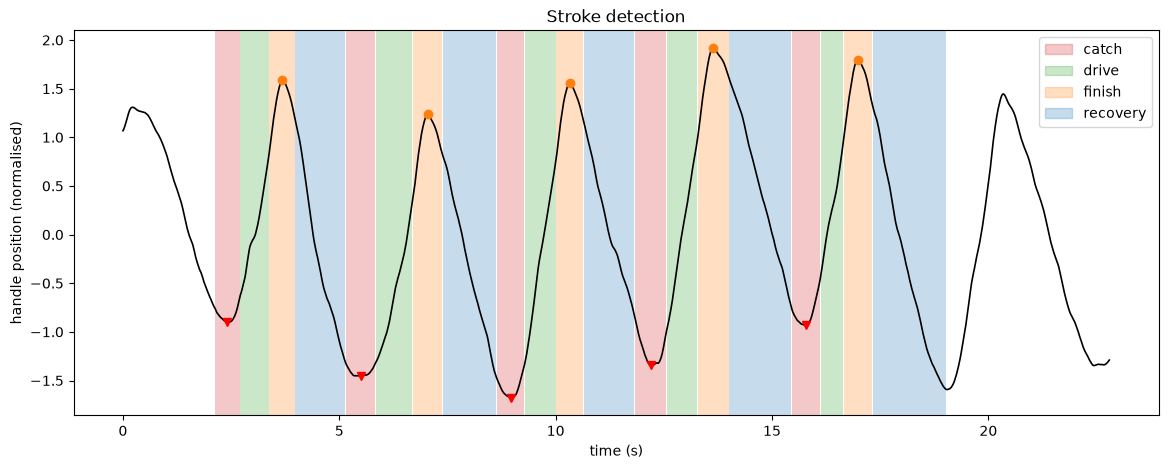

In [31]:
# plot the handle signal with the phases shaded

PHASE_COLORS = {"catch": "tab:red", "drive": "tab:green", "finish": "tab:orange", "recovery": "tab:blue"}

def plot_strokes(signal, strokes, phases, fps):
    t = np.arange(len(signal)) / fps
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(t, signal, color="black", lw=1.2)
    start = 0
    for i in range(1, len(phases) + 1):
        if i == len(phases) or phases[i] != phases[start]:
            if phases[start]:
                ax.axvspan(t[start], t[i - 1], color=PHASE_COLORS[phases[start]], alpha=0.25, lw=0)
            start = i
    ax.plot([s["catch"] / fps for s in strokes], [signal[s["catch"]] for s in strokes], "rv", label="catch")
    ax.plot([s["finish"] / fps for s in strokes], [signal[s["finish"]] for s in strokes], "o", color="tab:orange", label="finish")
    handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.25) for c in PHASE_COLORS.values()]
    ax.legend(handles, PHASE_COLORS.keys(), loc="upper right")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("handle position (normalised)")
    ax.set_title("Stroke detection")

plot_strokes(signal, strokes, phases, fps)

In [25]:
# write a video annotated with pose, joint angles, the current phase and the stroke rate

def annotate_strokes_video(input_path, output_path, fps, width, height, points, angles, phases, strokes):
    cap = cv2.VideoCapture(input_path)
    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))
    if not cap.isOpened() or not writer.isOpened():
        cap.release()
        writer.release()
        raise RuntimeError("Could not open input or output video.")

    stroke_of_frame = np.zeros(len(phases), dtype=int)
    for i, s in enumerate(strokes, 1):
        stroke_of_frame[s["catch"]:s["next_catch"]] = i

    font_scale = max(0.8, width / 1600)
    thickness = max(2, round(font_scale * 2))
    try:
        for i in range(len(phases)):
            success, frame = cap.read()
            if not success:
                break
            if angles[i] is not None:
                landmarks = [SimpleNamespace(x=x / width, y=y / height) for x, y, _ in points[i]]
                frame = annotate_frame(frame, landmarks, angles[i], width, height)
            if phases[i]:
                s = strokes[stroke_of_frame[i] - 1]
                text = f"Stroke {stroke_of_frame[i]} | {phases[i].upper()} | {s['rate_spm']:.0f} spm"
                color = PHASE_COLORS[phases[i]]
                rgb = tuple(int(255 * c) for c in matplotlib.colors.to_rgb(color))[::-1]
                (tw, th), base = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
                cv2.rectangle(frame, (10, 10), (30 + tw, 30 + th + base), (20, 20, 20), cv2.FILLED)
                cv2.putText(frame, text, (20, 20 + th), cv2.FONT_HERSHEY_SIMPLEX, font_scale, rgb, thickness, cv2.LINE_AA)
            writer.write(frame)
    finally:
        cap.release()
        writer.release()

In [32]:
import matplotlib.colors

# extract pose series, build handle signal, detect strokes, label phases, and print stroke data
fps, width, height, points, angles = extract_pose_series("../assets/alex-erg.mp4")
signal = build_handle_signal(points, angles, fps)
knee = interpolate_nans(angle_series(angles, "knee"))
strokes = detect_strokes(signal, fps, knee)
phases = label_phases(strokes, len(signal))
print_stroke_data(strokes)


NameError: name 'print_stroke_data' is not defined

In [ ]:
# annotate strokes on the video and convert to H.264 format

annotate_strokes_video("../assets/alex-erg.mp4", "../assets/alex-erg-strokes.mp4", fps, width, height, points, angles, phases, strokes)
convert_to_h264("../assets/alex-erg-strokes.mp4", "../assets/alex-erg-strokes-h264.mp4")